# Case Study (IA / Lab CA)
## Quantum-Inspired Genetic Algorithm (QIGA) for Feature Selection in Drug Discovery (BBBP)

**Objective:**  
Train a classifier to predict BBBP penetration (`p_np`) using SMILES strings, then apply a **Quantum-Inspired Genetic Algorithm (QIGA)** to select the best subset of features and compare results against baseline.

**Dataset columns used:**
- `smiles` → molecular string representation
- `p_np` → target label (0/1)

**Metrics reported:** Accuracy, Precision, Recall, F1, Execution Time

In [1]:
!pip -q install scikit-learn matplotlib pandas numpy tqdm

In [22]:


import os, time, json, numpy as np
from pathlib import Path

RUN_NAME = "QIGA_FeatureSelection_BBBP"
OUT_DIR = Path(f"/content/{RUN_NAME}_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved to:", OUT_DIR)

Outputs will be saved to: /content/QIGA_FeatureSelection_BBBP_outputs


## Step 1: Load BBBP Dataset

We load `BBBP.csv` and verify:
- dataset schema
- missing values
- class distribution

In [2]:
from google.colab import files
import pandas as pd

print("Upload BBBP.csv")
uploaded = files.upload()

csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

print("\nMissing values:\n", df.isnull().sum())
print("\nLabel distribution (p_np):\n", df["p_np"].value_counts())

Upload BBBP.csv


Saving BBBP.csv to BBBP.csv
Shape: (2050, 4)
Columns: ['num', 'name', 'p_np', 'smiles']


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...



Missing values:
 num       0
name      0
p_np      0
smiles    0
dtype: int64

Label distribution (p_np):
 p_np
1    1567
0     483
Name: count, dtype: int64


## Step 2: Feature Engineering (No RDKit)

Since RDKit is not available on this runtime, we use an alternative representation:

### SMILES → TF-IDF Character n-grams
- Converts SMILES strings into a **high-dimensional sparse feature matrix**
- Captures chemical sub-structure patterns as character fragments
- Perfect for feature selection (many features)

We use:
- analyzer = 'char'
- ngram_range = (2, 6)
- max_features = 20000 (can be tuned)

In [3]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

smiles = df["smiles"].astype(str).values
y = df["p_np"].astype(int).values

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 6),
    max_features=20000
)

X = vectorizer.fit_transform(smiles)  # sparse matrix
print("X shape:", X.shape, " (samples x features)")
print("Sparse density approx:", X.nnz / (X.shape[0] * X.shape[1]))

X shape: (2050, 20000)  (samples x features)
Sparse density approx: 0.009286243902439024


## Step 3: Train/Validation/Test Split (Stratified)

We split the dataset while keeping class ratio stable:
- Train: 70%
- Validation: 15%
- Test: 15%

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

Train: (1435, 20000)
Valid: (307, 20000)
Test : (308, 20000)


## Step 4: Baseline Model (No Feature Selection)

We train a baseline model using **all features**.

Model:
- Logistic Regression (fast + works well on sparse features)

We measure:
- Accuracy, Precision, Recall, F1
- Execution Time

In [14]:
import time, json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_lr(Xtr, ytr, Xte, yte):
    start = time.time()

    model = LogisticRegression(max_iter=2000, n_jobs=-1)
    model.fit(Xtr, ytr)

    preds = model.predict(Xte)
    end = time.time()

    metrics = {
        "accuracy": float(accuracy_score(yte, preds)),
        "precision": float(precision_score(yte, preds, zero_division=0)),
        "recall": float(recall_score(yte, preds, zero_division=0)),
        "f1": float(f1_score(yte, preds, zero_division=0)),
        "execution_time_sec": float(end - start)
    }
    return model, metrics

In [15]:
baseline_model, baseline_metrics = eval_lr(X_train, y_train, X_test, y_test)
baseline_metrics

{'accuracy': 0.8668831168831169,
 'precision': 0.8646616541353384,
 'recall': 0.9787234042553191,
 'f1': 0.9181636726546906,
 'execution_time_sec': 1.0777406692504883}

## Step 5: QIGA for Feature Selection

We apply Quantum-Inspired Genetic Algorithm (QIGA) to select the best subset of features.

### Representation
- Each feature has a selection probability p
- We sample masks (0/1) using p
- Fitness uses **validation accuracy** minus penalty for too many features

### Fitness Function
fitness = validation_accuracy − penalty*(selected_features / total_features)

In [16]:
from tqdm import tqdm
import numpy as np
from sklearn.base import clone

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sample_population(theta, pop_size, rng):
    p = sigmoid(theta)
    return (rng.random((pop_size, len(theta))) < p).astype(np.int8)

def fitness(mask, Xtr, ytr, Xva, yva,
            penalty_weight=0.04,
            min_feats=100,
            max_feats=800):

    idx = np.where(mask == 1)[0]
    n_selected = len(idx)
    total_feats = Xtr.shape[1]

    # Hard constraints
    if n_selected < min_feats or n_selected > max_feats:
        return -1e9, {"acc": 0.0, "n_feats": int(n_selected)}

    model = LogisticRegression(max_iter=2000, n_jobs=-1)
    model.fit(Xtr[:, idx], ytr)
    preds = model.predict(Xva[:, idx])
    acc = accuracy_score(yva, preds)

    # Penalize using too many features
    size_penalty = penalty_weight * (n_selected / max_feats)

    fitness_score = acc - size_penalty

    return float(fitness_score), {
        "acc": float(acc),
        "n_feats": int(n_selected)
    }

from tqdm import tqdm
import numpy as np
import pandas as pd

def qiga(Xtr, ytr, Xva, yva,
         pop_size=22, iters=30, lr=0.30,
         penalty_weight=0.04,
         min_feats=100,
         max_feats=800,
         seed=7):

    rng = np.random.default_rng(seed)
    n_feat = Xtr.shape[1]

    theta = np.full(n_feat, -2.0, dtype=np.float32)  # p ~ 0.12  -> expected ~480/4000
    history = []

    best_fit, best_mask, best_info = -1e18, None, None

    for t in tqdm(range(iters), desc="QIGA iterations"):
        pop = sample_population(theta, pop_size, rng)

        fits, infos = [], []
        for i in range(pop_size):
            f, info = fitness(
                pop[i], Xtr, ytr, Xva, yva,
                penalty_weight=penalty_weight,
                min_feats=min_feats,
                max_feats=max_feats
            )
            fits.append(f)
            infos.append(info)

        i_best = int(np.argmax(fits))
        gen_best_mask = pop[i_best].copy()
        gen_best_fit = float(fits[i_best])
        gen_best_info = infos[i_best]

        if gen_best_fit > best_fit:
            best_fit, best_mask, best_info = gen_best_fit, gen_best_mask, gen_best_info

        # Update toward best mask
        delta = (gen_best_mask * 2 - 1).astype(np.float32)
        theta = np.clip(theta + lr * delta, -4, 4)

        history.append({
            "iter": t+1,
            "gen_best_acc": gen_best_info["acc"],
            "gen_best_n_feats": gen_best_info["n_feats"],
            "global_best_acc": best_info["acc"],
            "global_best_n_feats": best_info["n_feats"]
        })

    return best_mask, best_fit, best_info, pd.DataFrame(history)

## Step 6: Reduce Candidate Space (Speed Optimization)

TF-IDF can produce up to 20,000 features. Running QIGA directly on all features is slow.

So we first select **top-K features** using a simple statistical filter (variance).
Then QIGA selects the best subset from these top-K features.

This keeps IA runtime practical while still demonstrating:
- baseline vs optimization
- reduced feature count
- performance comparison

In [17]:
from sklearn.feature_selection import VarianceThreshold

K = 4000  # candidate features for QIGA
# Get variance per feature (approx) using sparse mean/variance approach
# We'll use a VarianceThreshold to remove very low variance, then cap to top-K by variance.

# Convert sparse -> compute variance
X_train_dense_stats = X_train.copy()

# Compute feature variances for sparse:
mean = X_train_dense_stats.mean(axis=0).A1
mean_sq = X_train_dense_stats.multiply(X_train_dense_stats).mean(axis=0).A1
var = mean_sq - mean**2

topk_idx = np.argsort(var)[::-1][:K]

Xtr_k = X_train[:, topk_idx]
Xva_k = X_valid[:, topk_idx]
Xte_k = X_test[:, topk_idx]

print("Candidate feature space:", Xtr_k.shape)

Candidate feature space: (1435, 4000)


## Step 7: Run QIGA on Candidate Features

In [18]:
start = time.time()

best_mask, best_fit, best_info, hist_df = qiga(
    Xtr_k, y_train,
    Xva_k, y_valid,
    pop_size=22,
    iters=30,
    lr=0.30,
    penalty_weight=0.04,   # ✅ correct name
    min_feats=100,
    max_feats=800,         # ✅ enforce constraint
    seed=7
)

qiga_runtime = time.time() - start
selected_idx_local = np.where(best_mask == 1)[0]
selected_idx_global = topk_idx[selected_idx_local]

print("QIGA runtime (sec):", round(qiga_runtime, 2))
print("Selected features:", len(selected_idx_local), "(must be <= 800)")
print("Best validation acc:", best_info["acc"])

QIGA iterations: 100%|██████████| 30/30 [00:02<00:00, 12.72it/s]

QIGA runtime (sec): 2.36
Selected features: 420 (must be <= 800)
Best validation acc: 0.8273615635179153


## Step 8: Train Final Model on Selected Features + Test Evaluation

In [19]:
# Build selected feature matrices
Xtr_sel = X_train[:, selected_idx_global]
Xte_sel = X_test[:, selected_idx_global]

# Train & evaluate on test set using selected features
qiga_model, qiga_test_metrics = eval_lr(Xtr_sel, y_train, Xte_sel, y_test)

print("Baseline Test Metrics:", baseline_metrics)
print("QIGA Test Metrics:", qiga_test_metrics)
print("Selected features:", len(selected_idx_local))

Baseline Test Metrics: {'accuracy': 0.8668831168831169, 'precision': 0.8646616541353384, 'recall': 0.9787234042553191, 'f1': 0.9181636726546906, 'execution_time_sec': 1.0777406692504883}
QIGA Test Metrics: {'accuracy': 0.8246753246753247, 'precision': 0.8220640569395018, 'recall': 0.9829787234042553, 'f1': 0.8953488372093024, 'execution_time_sec': 0.012594461441040039}
Selected features: 420


## Step 9: Plots (as required)

We generate:
1. QIGA progress curve (accuracy vs iteration)
2. Feature count trend vs iteration
3. Baseline vs QIGA metrics comparison bar chart

<Figure size 640x480 with 0 Axes>

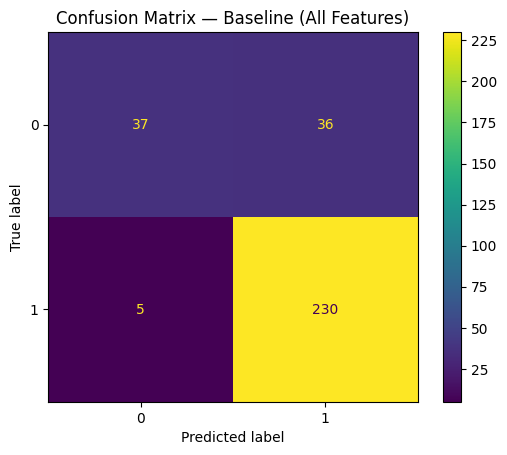

<Figure size 640x480 with 0 Axes>

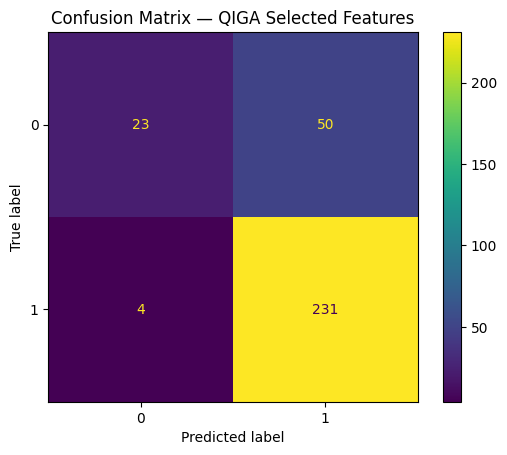

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Baseline predictions
y_pred_base = baseline_model.predict(X_test)

# QIGA predictions (selected features test matrix)
y_pred_qiga = qiga_model.predict(Xte_sel)

# Confusion matrices
cm_base = confusion_matrix(y_test, y_pred_base)
cm_qiga = confusion_matrix(y_test, y_pred_qiga)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base)
disp.plot(values_format='d')
plt.title("Confusion Matrix — Baseline (All Features)")
plt.grid(False)
plt.savefig(OUT_DIR / "cm_baseline.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qiga)
disp.plot(values_format='d')
plt.title("Confusion Matrix — QIGA Selected Features")
plt.grid(False)
plt.savefig(OUT_DIR / "cm_qiga.png", dpi=200, bbox_inches="tight")
plt.show()

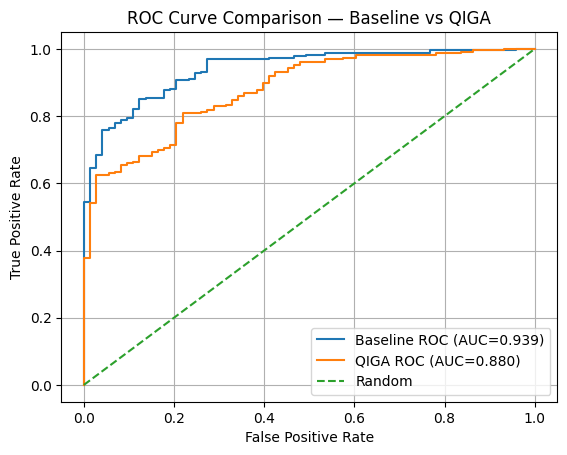

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
base_proba = baseline_model.predict_proba(X_test)[:, 1]
qiga_proba = qiga_model.predict_proba(Xte_sel)[:, 1]

fpr_b, tpr_b, _ = roc_curve(y_test, base_proba)
fpr_q, tpr_q, _ = roc_curve(y_test, qiga_proba)

auc_b = auc(fpr_b, tpr_b)
auc_q = auc(fpr_q, tpr_q)

plt.figure()
plt.plot(fpr_b, tpr_b, label=f"Baseline ROC (AUC={auc_b:.3f})")
plt.plot(fpr_q, tpr_q, label=f"QIGA ROC (AUC={auc_q:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Baseline vs QIGA")
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR / "roc_baseline_vs_qiga.png", dpi=200, bbox_inches="tight")
plt.show()

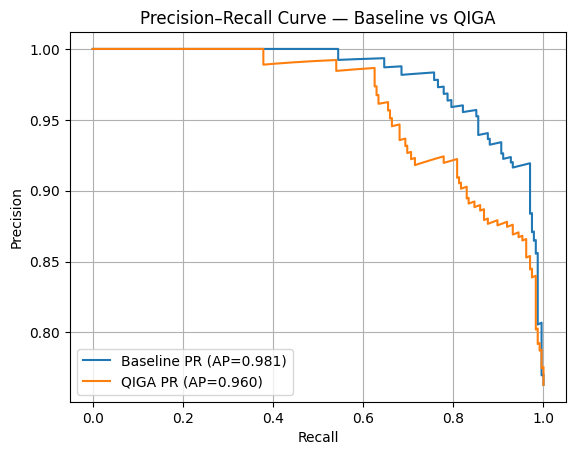

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

prec_b, rec_b, _ = precision_recall_curve(y_test, base_proba)
prec_q, rec_q, _ = precision_recall_curve(y_test, qiga_proba)

ap_b = average_precision_score(y_test, base_proba)
ap_q = average_precision_score(y_test, qiga_proba)

plt.figure()
plt.plot(rec_b, prec_b, label=f"Baseline PR (AP={ap_b:.3f})")
plt.plot(rec_q, prec_q, label=f"QIGA PR (AP={ap_q:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Baseline vs QIGA")
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR / "pr_baseline_vs_qiga.png", dpi=200, bbox_inches="tight")
plt.show()

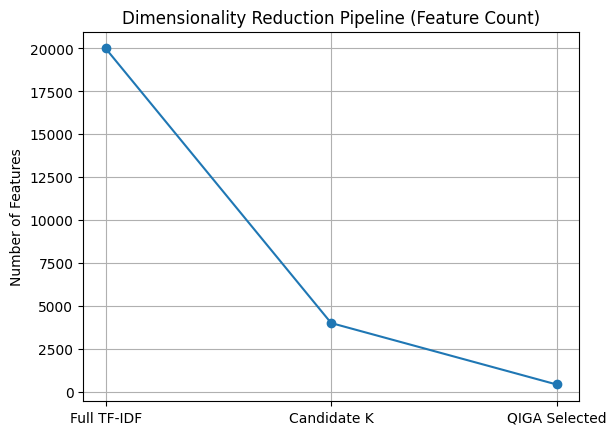

In [32]:
import matplotlib.pyplot as plt

baseline_feats = X_train.shape[1]     # full TF-IDF features (e.g., 20000)
candidate_feats = Xtr_k.shape[1]      # K (e.g., 4000)
selected_feats = len(selected_idx_local)  # e.g., 420

plt.figure()
stages = ["Full TF-IDF", "Candidate K", "QIGA Selected"]
vals = [baseline_feats, candidate_feats, selected_feats]
plt.plot(stages, vals, marker="o")
plt.ylabel("Number of Features")
plt.title("Dimensionality Reduction Pipeline (Feature Count)")
plt.grid(True)
plt.savefig(OUT_DIR / "feature_reduction_pipeline.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
import json, shutil
from pathlib import Path

OUT_DIR = Path("/content/QIGA_BBBP_outputs")
OUT_DIR.mkdir(exist_ok=True)

# Save metrics
with open(OUT_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

with open(OUT_DIR / "qiga_metrics.json", "w") as f:
    payload = dict(qiga_test_metrics)
    payload["qiga_runtime_sec"] = float(qiga_runtime)
    payload["selected_features"] = int(len(selected_idx_local))
    payload["candidate_features"] = int(Xtr_k.shape[1])
    payload["best_valid_acc"] = float(best_info["acc"])
    json.dump(payload, f, indent=2)

# Save QIGA history + selected indices
hist_df.to_csv(OUT_DIR / "qiga_history.csv", index=False)
np.save(OUT_DIR / "selected_feature_indices.npy", selected_idx_global)

# Save run config (important for report writing)
run_config = {
    "feature_method": {
        "type": "TFIDF_char_ngrams",
        "ngram_range": [2, 6],
        "max_features": 20000
    },
    "candidate_selection": {
        "method": "topK_variance",
        "K": int(Xtr_k.shape[1])
    },
    "qiga_params": {
        "pop_size": 22,
        "iters": 30,
        "lr": 0.30,
        "penalty_weight": 0.04,
        "min_feats": 100,
        "max_feats": 800,
        "seed": 7
    }
}

with open(OUT_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

# Zip everything
zip_path = shutil.make_archive(str(OUT_DIR), "zip", root_dir=str(OUT_DIR))
print("✅ Created final ZIP:", zip_path)

✅ Created final ZIP: /content/QIGA_BBBP_outputs.zip


In [ ]:
import shutil
from pathlib import Path
from google.colab import files

# Make sure this matches your output folder
OUT_DIR = Path("/content/QIGA_BBBP_outputs")

# Collect all PNG files
png_files = list(OUT_DIR.glob("*.png"))

if len(png_files) == 0:
    print("❌ No PNG graphs found in:", OUT_DIR)
else:
    print("Found graphs:")
    for f in png_files:
        print("-", f.name)

    # Create zip file
    zip_path = shutil.make_archive(str(OUT_DIR / "QIGA_graphs"), "zip", root_dir=str(OUT_DIR))
    print("\n✅ Created ZIP:", zip_path)

    # Download automatically
    files.download(zip_path)

Found graphs:
- cm_baseline.png
- pr_baseline_vs_qiga.png
- feature_reduction_pipeline.png
- roc_baseline_vs_qiga.png
- cm_qiga.png
